## 渗出物分割 - SVM / 逻辑回归 vs U-Net

本 notebook 仅作为 **Google Colab 运行器**。具体实现位于 `src/` 中，因此 Colab 只负责安装依赖、克隆仓库、设置参数，并调用 `run_experiment(...)`。

**比较的方法**

1. 传统机器学习：预处理 -> 候选区域分析 -> 手工特征 -> SVM 和逻辑回归
2. 深度学习：使用 ImageNet 预训练编码器的 U-Net



## 1. 配置环境


In [1]:
import subprocess, sys, torch

print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None - please switch to a GPU runtime")
subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "segmentation-models-pytorch==0.3.4",
    "opencv-python-headless",
    "scikit-image",
    "scikit-learn",
    "scipy",
], check=True)
print("Dependencies installed")


GPU: Tesla T4
Dependencies installed


## 2. 获取数据和模块

默认情况下，这会克隆包含数据和解耦后的 `src/` 模块的 GitHub 仓库。如果你 fork 或重命名了该仓库，只需修改 `REPO_URL`。



In [2]:
import os, sys, subprocess

REPO_URL = "https://github.com/LeafTraces/ML-Project.git"   # Change this if needed
PROJECT_DIR = "ML-Project"
DATA_SUBDIR = "topic/眼底图像的渗出液分割/EX数据"

if not os.path.isdir(PROJECT_DIR):
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, PROJECT_DIR], check=True)

for module_path in [os.getcwd(), PROJECT_DIR]:
    if module_path not in sys.path:
        sys.path.insert(0, module_path)

DATA_ROOT = os.path.join(PROJECT_DIR, DATA_SUBDIR)
assert os.path.isdir(os.path.join(DATA_ROOT, "images")), "Data not found; check REPO_URL and DATA_SUBDIR"
assert os.path.isdir("src") or os.path.isdir(os.path.join(PROJECT_DIR, "src")), "src modules not found; make sure the repository contains the decoupled code"
print("Data root:", DATA_ROOT)


Data root: ML-Project/topic/眼底图像的渗出液分割/EX数据


## 3. 参数配置


In [3]:
SEED = 42
WORK_W, WORK_H = 672, 448
IMG_SIZE = (WORK_W, WORK_H)
VAL_RATIO = 0.18

UNET_ENCODER = "resnet34"
EPOCHS = 60
BATCH = 8
LR = 1e-3
OUT = "outputs"


## 4. 运行实验

这一步会运行数据加载、预处理、SVM/LR 训练、U-Net 训练、统一评估、图像生成以及结果导出。



DEVICE: cuda
fit 27 / val 5 / test 15
前景占比: mean 0.2181%  median 0.1053%  max 1.4509%  —— 极端类别不平衡


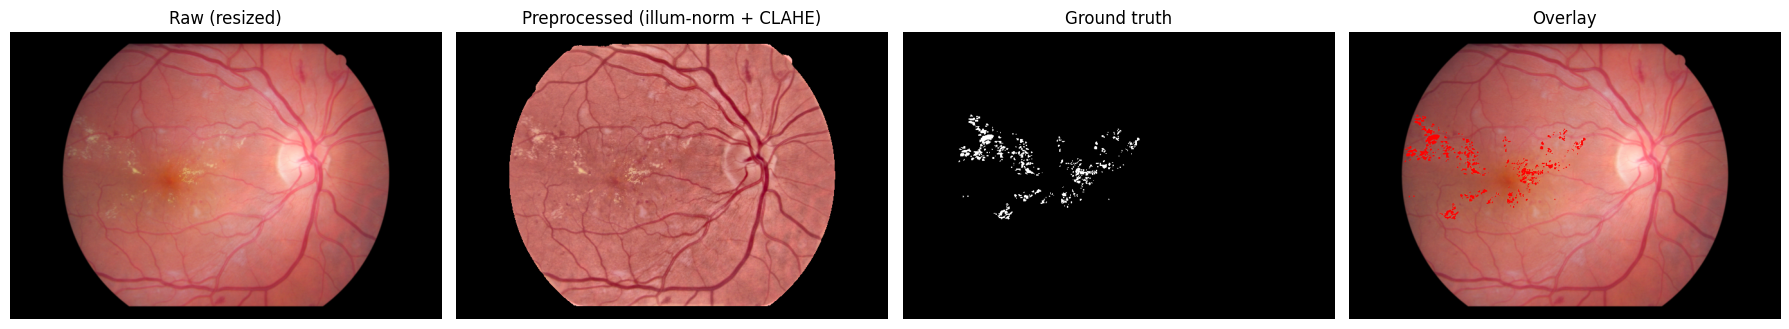

候选检测召回上限: 0.557  训练样本 (254448, 14)  正例率 0.062
[方法一-SVM] 学习时间 5.0s 阈值0.65 Dice 0.103 IoU 0.054 Recall 0.203 ROC-AUC 0.846 PR-AUC 0.156
[方法一-Logistic Regression] 学习时间 3.2s 阈值0.95 Dice 0.086 IoU 0.045 Recall 0.428 ROC-AUC 0.842 PR-AUC 0.152


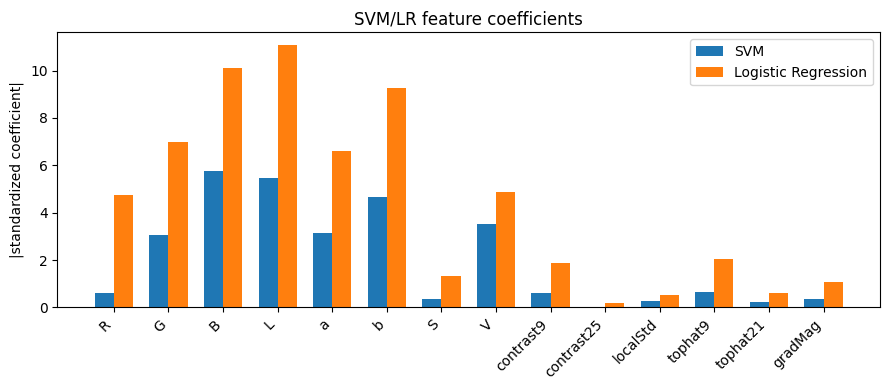

Downloading: "https://download.pytorch.org/models/resnet34-333f7ec4.pth" to /root/.cache/torch/hub/checkpoints/resnet34-333f7ec4.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 324MB/s]
/content/ML-Project/src/unet_model.py:118: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/content/ML-Project/src/unet_model.py:129: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


epoch  0  loss 0.8571  val_dice 0.0082  best 0.0082
epoch  5  loss 0.5949  val_dice 0.1808  best 0.2192
epoch 10  loss 0.5365  val_dice 0.3412  best 0.3706
epoch 15  loss 0.5015  val_dice 0.4004  best 0.4004
epoch 20  loss 0.4660  val_dice 0.3930  best 0.4485
epoch 25  loss 0.4453  val_dice 0.4386  best 0.4662
epoch 30  loss 0.4127  val_dice 0.4793  best 0.4793
epoch 35  loss 0.3893  val_dice 0.4996  best 0.5123
epoch 40  loss 0.3731  val_dice 0.5024  best 0.5132
epoch 45  loss 0.3518  val_dice 0.5325  best 0.5325
epoch 50  loss 0.3378  val_dice 0.5291  best 0.5325
epoch 55  loss 0.3386  val_dice 0.5294  best 0.5325
epoch 59  loss 0.3312  val_dice 0.5282  best 0.5325
U-Net 学习时间 94.8s  最佳 val_dice 0.5325
[方法二-UNet] 阈值0.95 Dice 0.506 IoU 0.339 Recall 0.555 ROC-AUC 0.959 PR-AUC 0.732


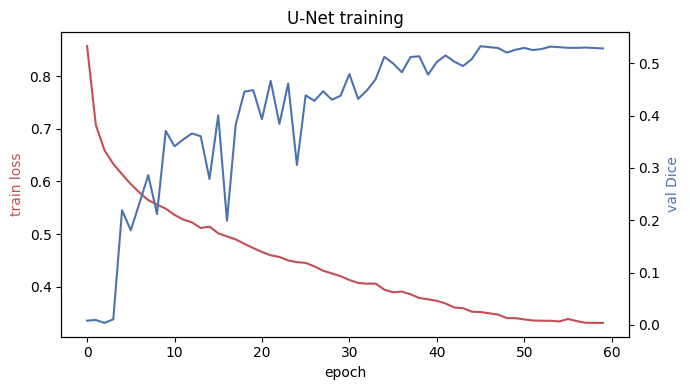

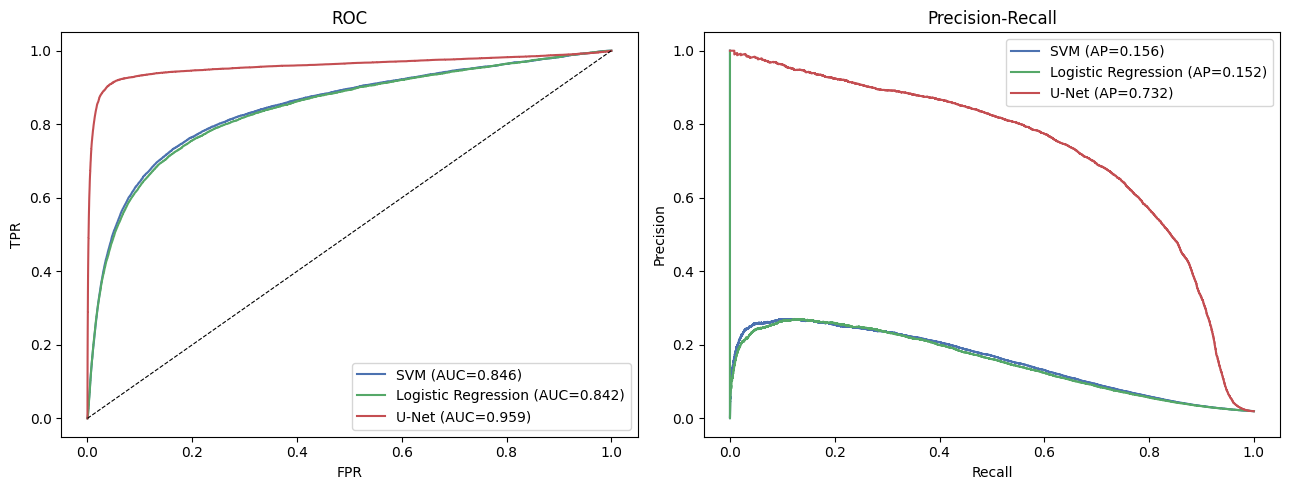

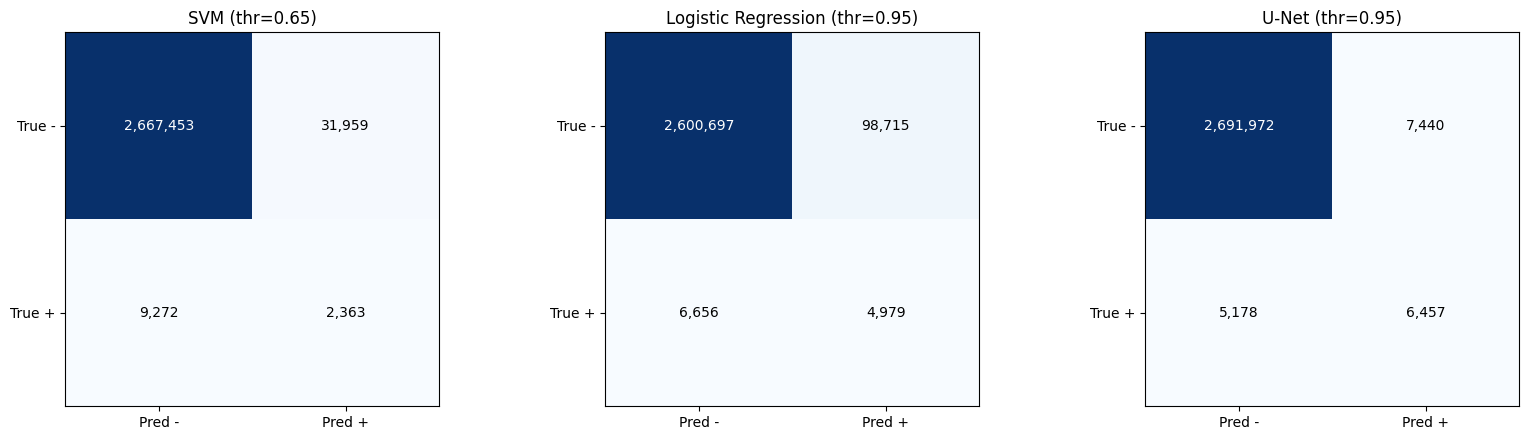

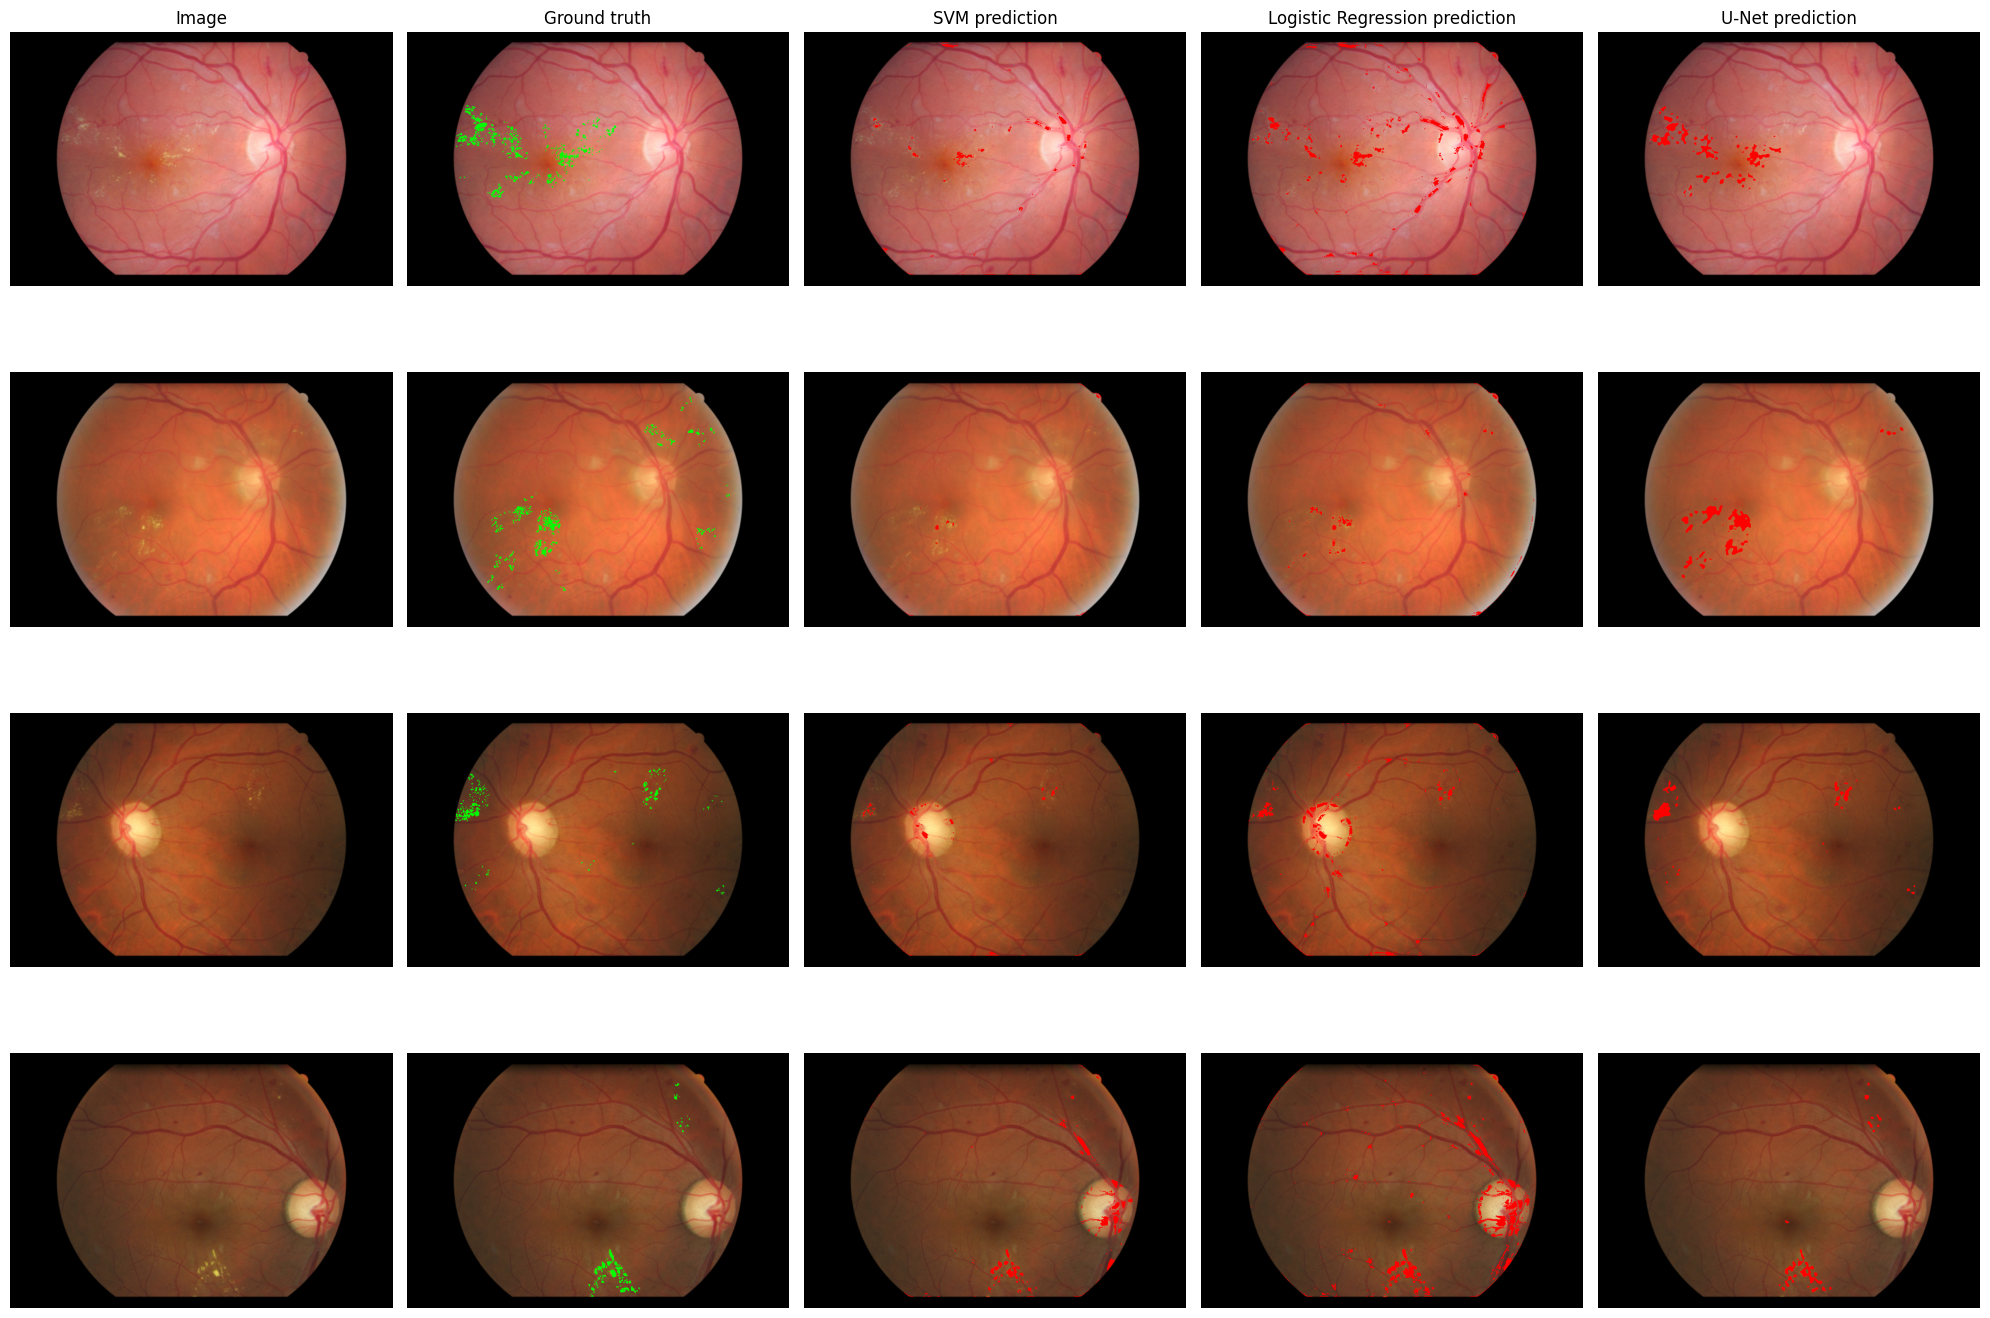

已保存 outputs/results.json 与 results_table.csv



Method,SVM (传统ML),Logistic Regression (传统ML),U-Net (resnet34)
Learn time(s),5.0000,3.2000,94.8000
Threshold,0.6500,0.9500,0.9500
Accuracy,0.9848,0.9611,0.9953
Precision,0.0688,0.0480,0.4646
Recall,0.2031,0.4279,0.5550
Specificity,0.9882,0.9634,0.9972
F1,0.1028,0.0863,0.5058
IoU,0.0542,0.0451,0.3385
Dice,0.1028,0.0863,0.5058
ROC-AUC,0.8459,0.8416,0.9585


In [4]:
from src.experiment import run_experiment

df, results = run_experiment(
    data_root=DATA_ROOT,
    seed=SEED,
    work_size=IMG_SIZE,
    val_ratio=VAL_RATIO,
    unet_encoder=UNET_ENCODER,
    epochs=EPOCHS,
    batch=BATCH,
    lr=LR,
    out_dir=OUT,
)


## 5. 下载输出

运行后会生成 `outputs/results_table.csv`、`outputs/results.json`，以及位于 `outputs/figures/` 下的图像。



In [5]:
import shutil

shutil.make_archive("exudate_outputs", "zip", OUT)
print("Created exudate_outputs.zip with figures, results.json, and results_table.csv")
try:
    from google.colab import files
    files.download("exudate_outputs.zip")
except Exception:
    print("If auto-download is unavailable, download exudate_outputs.zip from the Colab file panel")


Created exudate_outputs.zip with figures, results.json, and results_table.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

### 输出文件

* `outputs/results_table.csv`：SVM、逻辑回归和 U-Net 的统一指标表。
* `outputs/results.json`：原始指标、混淆矩阵和线性模型特征系数。
* `outputs/figures/`：预处理、线性系数、U-Net 训练曲线、ROC/PR、混淆矩阵和定性对比。

